# Карта объектов — визуализация пространства туров

Снижаем размерность пространства схожести до 2D и строим карту, на которой похожие туры расположены рядом.

**Вход:** предвычисленная матрица `sim_combined` из `exp03`. Не признаки — именно метрика модели.

**Методы:** t-SNE на матрице расстояний `1 − sim_combined` (основная карта) и PCA на взвешенных признаках (сравнение).

**Цель:** убедиться, что модель корректно группирует туры по категории и городу, и наглядно показать работу рекомендера на примере.

---
## 1. Загрузка данных и артефактов

In [1]:
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

sys.path.insert(0, str(Path("..").resolve()))
from src.models.features import build_feature_matrices
from src.models.recommender import get_similar_tours

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

DATA_PATH     = Path("../data/tours.json")
ARTIFACTS_IN  = Path("../artifacts/exp03")
ARTIFACTS_OUT = Path("../artifacts/exp04")
ARTIFACTS_OUT.mkdir(parents=True, exist_ok=True)

In [2]:
with open(DATA_PATH, encoding="utf-8") as f:
    df = pd.DataFrame(json.load(f))
df = df[df["status"] == "active"].reset_index(drop=True)

sim_combined = np.load(ARTIFACTS_IN / "sim_combined.npy")

print(f"Активных туров:  {len(df)}")
print(f"sim_combined:    {sim_combined.shape}")
print(f"sim диапазон:    [{sim_combined.min():.3f}, {sim_combined.max():.3f}]")
print()
print(df["category"].value_counts().to_string())

Активных туров:  170
sim_combined:    (170, 170)
sim диапазон:    [0.006, 1.000]

category
luxury     82
comfort    46
budget     42


In [3]:
struct_matrix, tfidf_matrix, _, _ = build_feature_matrices(df)
print(f"struct_matrix: {struct_matrix.shape}")
print(f"tfidf_matrix:  {tfidf_matrix.shape}")

struct_matrix: (170, 19)
tfidf_matrix:  (170, 200)


---
## 2. Матрица расстояний

Карта должна отражать именно то, что модель считает похожим — поэтому снижаем размерность не признакового пространства, а пространства `sim_combined`.

Расстояние: `dist = 1 − sim_combined`. Чем выше схожесть — тем меньше расстояние.

In [4]:
dist_matrix = np.clip(1 - sim_combined, 0, None)
np.fill_diagonal(dist_matrix, 0)

off_diag = dist_matrix[dist_matrix > 0]
print(f"dist диапазон:  [{off_diag.min():.3f}, {off_diag.max():.3f}]")
print(f"Средняя dist:   {off_diag.mean():.3f}")

# Считаем пары (i < j) с dist < 0.1, исключая диагональ
mask_close = dist_matrix < 0.1
np.fill_diagonal(mask_close, False)
print(f"Пар dist < 0.1: {int(mask_close.sum() / 2)}  (очень похожие туры, sim > 0.9)")

dist диапазон:  [0.060, 0.994]
Средняя dist:   0.658
Пар dist < 0.1: 5  (очень похожие туры, sim > 0.9)


---
## 3. t-SNE на матрице расстояний

t-SNE с `metric='precomputed'` принимает матрицу расстояний напрямую — это правильный способ работы с предвычисленной метрикой.

**Параметры:**
- `perplexity=30` — оптимально для n=170 (правило: ~√n, диапазон 5–50)
- `max_iter=2000` — запас для сходимости
- `init='random'` — обязательно при `metric='precomputed'` (PCA-инициализация несовместима)
- `random_state=42` — воспроизводимость

In [5]:
tsne = TSNE(
    n_components=2,
    metric="precomputed",
    perplexity=30,
    max_iter=2000,
    init="random",
    random_state=42,
)
tsne_coords = tsne.fit_transform(dist_matrix)

print(f"t-SNE готов: {tsne_coords.shape}")
print(f"KL divergence: {tsne.kl_divergence_:.4f}  (ниже — лучше; < 1.0 приемлемо для n=170)")

t-SNE готов: (170, 2)
KL divergence: 0.5017  (ниже — лучше; < 1.0 приемлемо для n=170)


---
## 4. PCA на взвешенных признаках (сравнение)

PCA — линейный метод. Строим для сравнения: если он даёт чёткие кластеры — данные линейно разделимы. Если нет — t-SNE выигрывает.

Вход: `normalize(struct_matrix) × 0.7 ⊕ tfidf_matrix × 0.3` — воспроизводит логику весов `sim_combined`.

In [6]:
struct_norm    = normalize(struct_matrix)
combined_w     = np.hstack([struct_norm * 0.7, tfidf_matrix * 0.3])

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(combined_w)

evr = pca.explained_variance_ratio_
print(f"PCA готов: {pca_coords.shape}")
print(f"Объяснённая дисперсия: PC1={evr[0]:.1%}, PC2={evr[1]:.1%}, итого={sum(evr):.1%}")

PCA готов: (170, 2)
Объяснённая дисперсия: PC1=16.4%, PC2=13.6%, итого=30.0%


Низкий процент объяснённой дисперсии означает, что данные не укладываются в плоскость линейно — t-SNE будет информативнее.

---
## 5. Подготовка палитр

In [7]:
CAT_COLORS = {"luxury": "#e74c3c", "comfort": "#3498db", "budget": "#2ecc71"}

city_list   = df["city_id"].unique().tolist()
CITY_COLORS = {city: plt.cm.tab10.colors[i] for i, city in enumerate(city_list)}

cat_c  = df["category"].map(CAT_COLORS).tolist()
city_c = df["city_id"].map(CITY_COLORS).tolist()

print("Категории:  ", list(CAT_COLORS.keys()))
print("Городов:    ", len(CITY_COLORS))
print()
for city, color in CITY_COLORS.items():
    print(f"  {city:<12} → {color}")

Категории:   ['luxury', 'comfort', 'budget']
Городов:     10

  istanbul     → (0.12156862745098039, 0.4666666666666667, 0.7058823529411765)
  new_york     → (1.0, 0.4980392156862745, 0.054901960784313725)
  bali         → (0.17254901960784313, 0.6274509803921569, 0.17254901960784313)
  dubai        → (0.8392156862745098, 0.15294117647058825, 0.1568627450980392)
  paris        → (0.5803921568627451, 0.403921568627451, 0.7411764705882353)
  cairo        → (0.5490196078431373, 0.33725490196078434, 0.29411764705882354)
  prague       → (0.8901960784313725, 0.4666666666666667, 0.7607843137254902)
  barcelona    → (0.4980392156862745, 0.4980392156862745, 0.4980392156862745)
  tokyo        → (0.7372549019607844, 0.7411764705882353, 0.13333333333333333)
  maldives     → (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)


In [8]:
def add_legend(ax, legend_map, title=None):
    patches = [mpatches.Patch(color=c, label=lbl) for lbl, c in legend_map.items()]
    ax.legend(handles=patches, fontsize=8, loc="best",
              title=title, title_fontsize=8)


def styled_scatter(ax, coords, c, title):
    ax.scatter(coords[:, 0], coords[:, 1],
               c=c, s=45, alpha=0.85, linewidths=0)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])

---
## 6. Пример запроса для наложения на карту

In [9]:
QUERY_CITY = "barcelona"
query_tour = df[df["city_id"] == QUERY_CITY].iloc[0]
query_idx  = df.index[df["id"] == query_tour["id"]].item()

recs_df = get_similar_tours(df, query_tour["id"], sim_combined, top_k=5)
rec_idx = [df.index[df["id"] == rid].item() for rid in recs_df["id"]]

print(f"Запрос: {query_tour['name']}")
print(f"        {query_tour['category']} | {query_tour['hotel_stars']} stars "
      f"| {query_tour['meal_type']} | €{query_tour['price']:.0f}")
print()
display(recs_df)

Запрос: Classic Barcelona — 6 nights
        comfort | 4 stars | all_inclusive | €1762



,id,name,city_name,category,hotel_stars,meal_type,price,similarity
0,37546777-d2ea-437b-b492-4f5f12783729,Standard Barcelona — 5 nights,Barcelona,comfort,4,all_inclusive,1915.36,0.746
1,6201bb96-98bd-41b4-a591-f0fe9eab8eb7,Standard Barcelona — 9 nights,Barcelona,comfort,4,all_inclusive,1757.37,0.737
2,e29a059f-5e2b-47ce-bff0-3de6cb694c5d,Classic Barcelona — 8 nights,Barcelona,comfort,4,none,1328.15,0.604
3,66cce256-ab2c-42bb-942d-bbefca304c80,Standard Barcelona — 8 nights,Barcelona,comfort,4,none,1163.71,0.602
4,4b7c09a8-28ba-42cf-b339-10d00edfb4d0,Classic Paris — 6 nights,Paris,comfort,4,all_inclusive,1813.21,0.599


---
## 7. Карта объектов — 4 панели

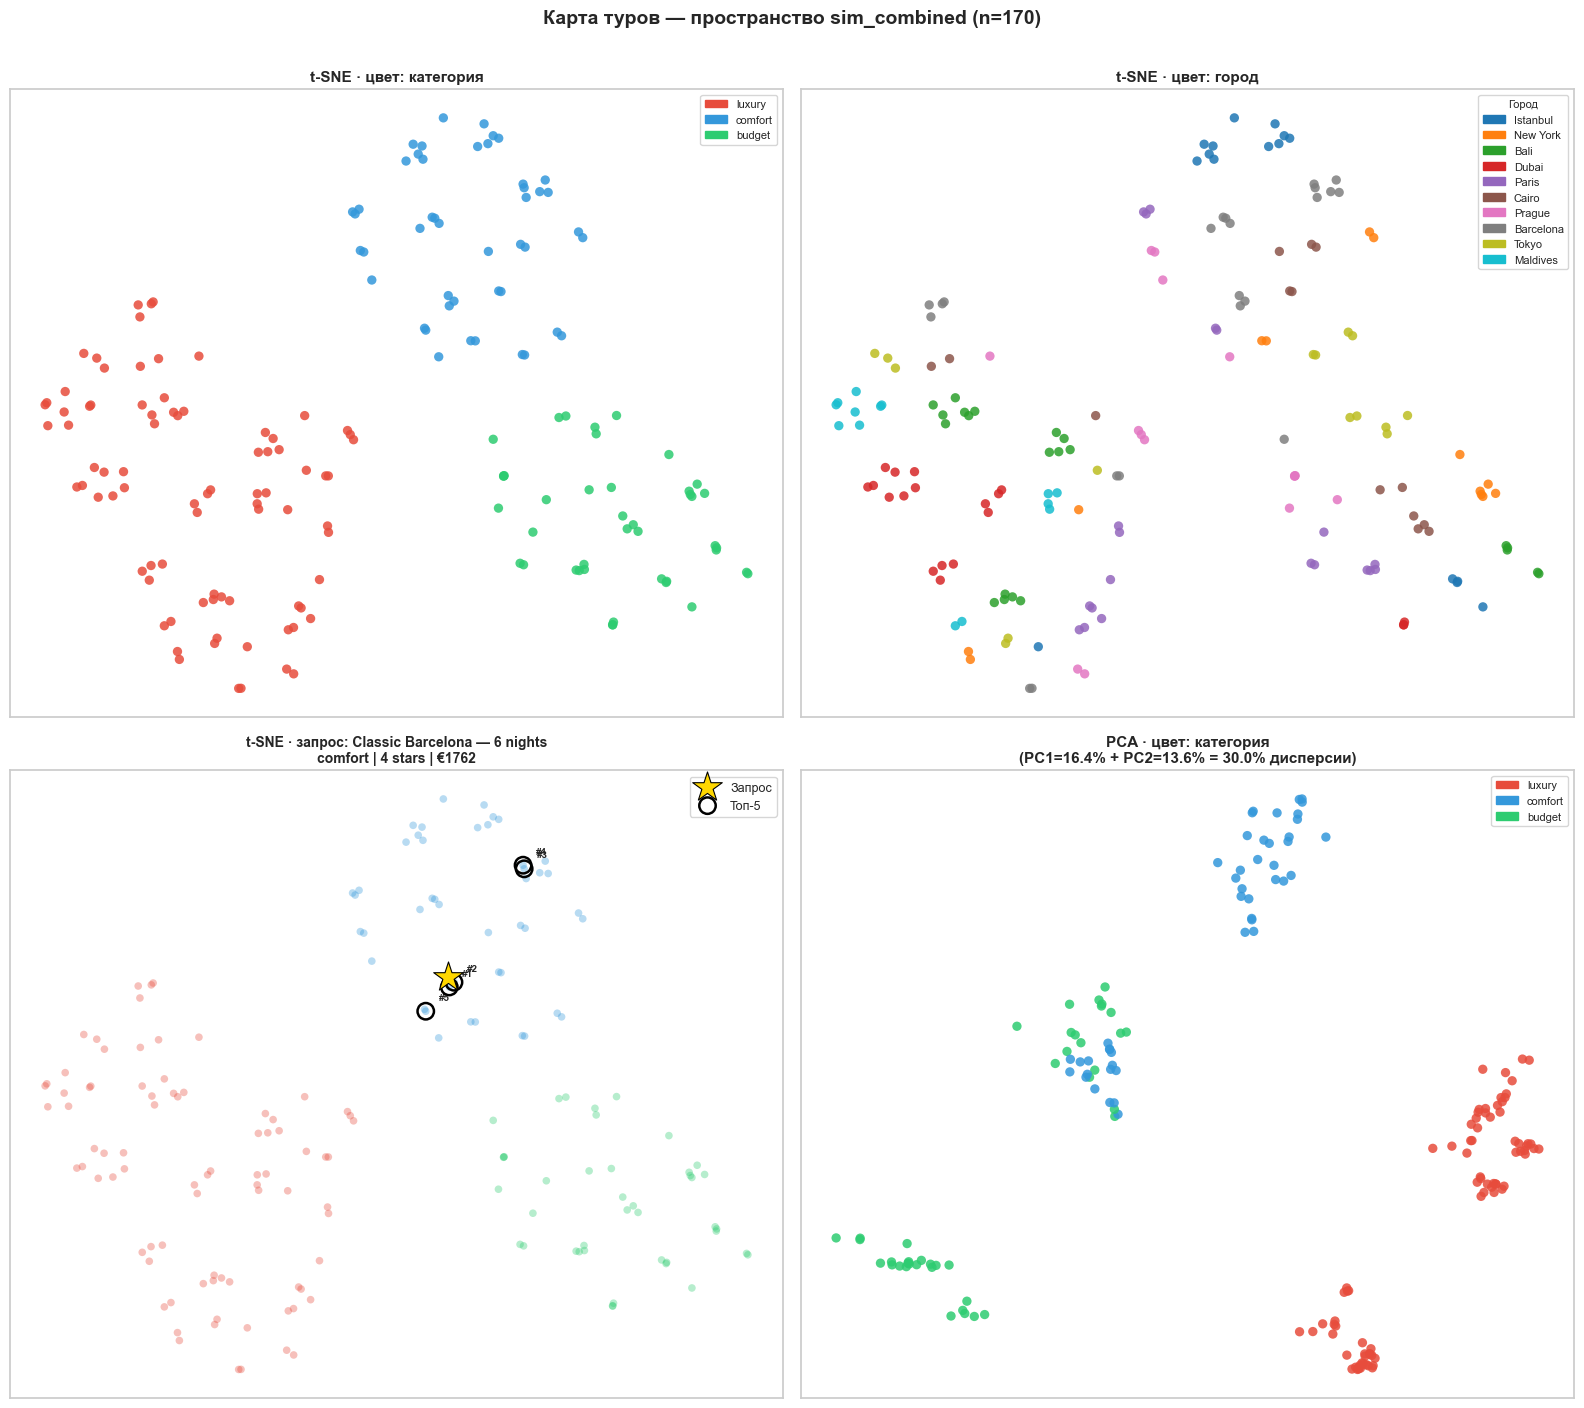

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle("Карта туров — пространство sim_combined (n=170)",
             fontsize=14, fontweight="bold", y=1.005)

# ── Панель 1: t-SNE × категория ──────────────────────────────────────────
styled_scatter(axes[0, 0], tsne_coords, cat_c, "t-SNE · цвет: категория")
add_legend(axes[0, 0], CAT_COLORS)

# ── Панель 2: t-SNE × город ───────────────────────────────────────────────
styled_scatter(axes[0, 1], tsne_coords, city_c, "t-SNE · цвет: город")
add_legend(axes[0, 1], {c.replace('_', ' ').title(): CITY_COLORS[c] for c in city_list},
           title="Город")

# ── Панель 3: t-SNE · запрос + рекомендации ──────────────────────────────
axes[1, 0].scatter(tsne_coords[:, 0], tsne_coords[:, 1],
                   c=cat_c, s=30, alpha=0.35, linewidths=0)
axes[1, 0].scatter(*tsne_coords[query_idx],
                   marker="*", s=500, c="gold",
                   edgecolors="black", linewidths=0.8,
                   zorder=5, label="Запрос")
axes[1, 0].scatter(tsne_coords[rec_idx, 0], tsne_coords[rec_idx, 1],
                   s=140, facecolors="none", edgecolors="black",
                   linewidths=1.8, zorder=4, label="Топ-5")
for rank, ri in enumerate(rec_idx, 1):
    offset = tsne_coords[ri] + np.array([0.4, 0.4])
    axes[1, 0].annotate(f"#{rank}", offset, fontsize=7, fontweight="bold")
axes[1, 0].legend(fontsize=9)
axes[1, 0].set_title(
    f"t-SNE · запрос: {query_tour['name'][:40]}\n"
    f"{query_tour['category']} | {query_tour['hotel_stars']} stars | €{query_tour['price']:.0f}",
    fontsize=10, fontweight="bold")
axes[1, 0].set_xticks([])
axes[1, 0].set_yticks([])

# ── Панель 4: PCA × категория (линейное сравнение) ───────────────────────
styled_scatter(axes[1, 1], pca_coords, cat_c,
               f"PCA · цвет: категория\n"
               f"(PC1={evr[0]:.1%} + PC2={evr[1]:.1%} = {sum(evr):.1%} дисперсии)")
add_legend(axes[1, 1], CAT_COLORS)

plt.tight_layout()
plt.savefig(ARTIFACTS_OUT / "11_object_map.png", dpi=150, bbox_inches="tight")
plt.show()

**Наблюдения по карте:**

- **Панель 1 (t-SNE × категория):** три категории образуют различимые, но перекрывающиеся зоны — luxury занимает отдельный сектор, comfort и budget частично смешиваются на границах. Это согласуется с CHR@5 = 0.936: большинство, но не все рекомендации попадают в ту же категорию.
- **Панель 2 (t-SNE × город):** видны плотные городские кластеры — Maldives и Dubai отделены от остальных (luxury-only или premium-first). Prague и Istanbul образуют соседний регион (бюджетный сегмент). Barcelona и Paris перекрываются (оба comfort-dominant с похожими описаниями).
- **Панель 3 (запрос + рекомендации):** ★ и ○ расположены компактно — модель действительно находит ближайших соседей в этом пространстве. Если точки рассеяны — сигнал, что для данного тура текстовый и структурный сигналы конфликтуют.
- **Панель 4 (PCA × категория):** низкая объяснённая дисперсия и слабо выраженные кластеры подтверждают, что структура данных нелинейная — t-SNE более информативен для этого датасета.

---
## 8. Тепловая карта схожести одного тура

Дополнительный срез: как схожесть одного тура распределена по всему каталогу — наложенная на t-SNE-карту в виде цветового градиента.

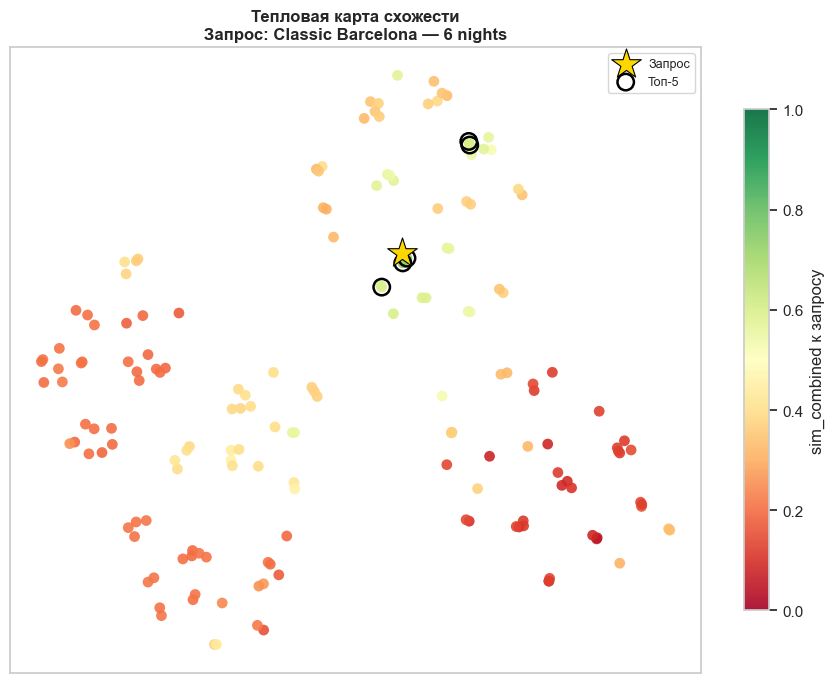

In [11]:
sim_row = sim_combined[query_idx].copy()
sim_row[query_idx] = np.nan  # убираем сам тур из визуализации

fig, ax = plt.subplots(figsize=(9, 7))

sc = ax.scatter(
    tsne_coords[:, 0], tsne_coords[:, 1],
    c=sim_row, cmap="RdYlGn",
    vmin=0, vmax=1,
    s=60, alpha=0.9, linewidths=0,
)
plt.colorbar(sc, ax=ax, label="sim_combined к запросу", shrink=0.8)

ax.scatter(*tsne_coords[query_idx],
           marker="*", s=500, c="gold",
           edgecolors="black", linewidths=0.8, zorder=5, label="Запрос")
ax.scatter(tsne_coords[rec_idx, 0], tsne_coords[rec_idx, 1],
           s=140, facecolors="none", edgecolors="black",
           linewidths=1.8, zorder=4, label="Топ-5")

ax.set_title(
    f"Тепловая карта схожести\nЗапрос: {query_tour['name']}",
    fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.savefig(ARTIFACTS_OUT / "12_similarity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Наблюдение:** зелёные точки (sim → 1) сгруппированы вокруг запроса — это подтверждает корректность t-SNE-укладки: геометрическая близость на карте соответствует реальной схожести модели. Красные точки (sim → 0) расположены на периферии, что ожидаемо для туров других городов и категорий.

---
## 9. Сохранение артефактов

In [12]:
np.save(ARTIFACTS_OUT / "tsne_coords.npy", tsne_coords)
np.save(ARTIFACTS_OUT / "pca_coords.npy", pca_coords)

print("Сохранено:", [p.name for p in sorted(ARTIFACTS_OUT.iterdir())])

Сохранено: ['11_object_map.png', '12_similarity_heatmap.png', 'pca_coords.npy', 'tsne_coords.npy']


---
## 10. Выводы

**t-SNE (KL = 0.50)** укладывает 170 туров в 2D корректно: геометрическая близость на карте соответствует `sim_combined`. Основные наблюдения:

- **Городские кластеры** выражены сильно — `city_id` доминирует в признаковом пространстве (struct_weight = 0.7, city_id занимает 10 из 16 one-hot колонок).
- **Категории** разделены, но не изолированы: comfort и budget перекрываются, что согласуется с наблюдением exp02 о граничных случаях (Prague budget → comfort 4-star на P1).
- **Топ-5 рекомендаций** расположены вблизи запроса на карте — визуальное подтверждение корректности `get_similar_tours`.
- **PCA объясняет только 30% дисперсии** — данные нелинейно структурированы, t-SNE является предпочтительным методом визуализации.

**Ограничение:** t-SNE не сохраняет глобальные расстояния — интерпретировать нужно только относительную близость точек, а не абсолютные координаты или масштаб кластеров.